# Modul 8: Deep Learning & Neural Network
**Project-Based Internship VINIX7**

Kelompok 3 (Universitas Sultan Ageng Tirtayasa)

Anggota Kelompok: Ahmad Jumhadi, Azhriler Lintang, Aura Salsa Azzahra

**Tahap 1: Persiapan Lingkungan & Pengumpulan Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import MobileNetV2

import torch

import os
import zipfile

import warnings
warnings.filterwarnings('ignore')

In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aurasalsaazzahra","key":"6fd200e9cb954438315f2a5c1cc39876"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d salmanabdu/tokopedia-product-reviews-2025

with zipfile.ZipFile('tokopedia-product-reviews-2025.zip', 'r') as zip_ref:
    zip_ref.extractall('reviews')

Dataset URL: https://www.kaggle.com/datasets/salmanabdu/tokopedia-product-reviews-2025
License(s): MIT
100% 3.54M/3.54M [00:00<00:00, 152MB/s]



In [ ]:
!kaggle datasets download -d paramaggarwal/fashion-product-images-dataset

with zipfile.ZipFile('fashion-product-images-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('fashion')

Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-dataset
License(s): MIT
100% 23.1G/23.1G [02:45<00:00, 150MB/s]



**Tahap 2: Klasifikasi Gambar Fashion (CNN)**

**1) Data Subsetting & Preprocessing**

### Mengapa Perlu Subsetting?
Dataset fashion image memiliki lebih dari 44.000 gambar. Memuat seluruhnya ke dalam memori RAM Google Colab (yang terbatas ~12 GB) akan menyebabkan **Out of Memory (OOM) error**. Oleh karena itu, kita:
- Memilih **3 kategori produk** yang paling sering muncul (Tshirts, Watches, Shoes).
- Membatasi maksimal **500 gambar per kategori** (total 1.500 gambar).

### Normalisasi Piksel (÷ 255)
Nilai piksel gambar berkisar antara 0–255. Membaginya dengan 255 menghasilkan rentang 0.0–1.0. Normalisasi ini penting karena:
- Mempercepat konvergensi gradient descent.
- Mencegah dominasi fitur berskala besar yang dapat mendistorsi training.

### Resize ke 64×64
Resolusi asli gambar bisa sangat besar (misalnya 400×600). Mereduksi ke 64×64 mengurangi jumlah parameter secara drastis dan mempercepat proses pelatihan, dengan trade-off: beberapa detail visual halus mungkin hilang.

In [ ]:
df = pd.read_csv('/content/fashion/fashion-dataset/styles.csv', on_bad_lines='skip')
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [ ]:
top_category = df['articleType'].value_counts().head(3).index
print("3 kategori produk yang paling banyak:", list(top_category))

3 kategori produk yang paling banyak: ['Tshirts', 'Shirts', 'Casual Shoes']


In [ ]:
df_filtered = df[df['articleType'].isin(top_category)]

df_subsetting = df_filtered.groupby('articleType').head(500)

In [ ]:
image_dir = '/content/fashion/fashion-dataset/images'

df_subsetting['image_path'] = df_subsetting['id'].apply(
    lambda x: os.path.join(image_dir, str(x) + '.jpg')
)

df_subsetting = df_subsetting[df_subsetting['image_path'].apply(os.path.exists)]

In [ ]:
print(df_subsetting.shape)
df_subsetting.head()

(1499, 11)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,/content/fashion/fashion-dataset/images/15970.jpg
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,/content/fashion/fashion-dataset/images/53759.jpg
5,1855,Men,Apparel,Topwear,Tshirts,Grey,Summer,2011.0,Casual,Inkfruit Mens Chain Reaction T-shirt,/content/fashion/fashion-dataset/images/1855.jpg
6,30805,Men,Apparel,Topwear,Shirts,Green,Summer,2012.0,Ethnic,Fabindia Men Striped Green Shirt,/content/fashion/fashion-dataset/images/30805.jpg
7,26960,Women,Apparel,Topwear,Shirts,Purple,Summer,2012.0,Casual,Jealous 21 Women Purple Shirt,/content/fashion/fashion-dataset/images/26960.jpg


In [ ]:
data_generator = ImageDataGenerator(
    rescale= 1./255,
    validation_split=0.2
)

train_data = data_generator.flow_from_dataframe(
    dataframe=df_subsetting,
    x_col='image_path',
    y_col='articleType',
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = data_generator.flow_from_dataframe(
    dataframe=df_subsetting,
    x_col='image_path',
    y_col='articleType',
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 1200 validated image filenames belonging to 3 classes.
Found 299 validated image filenames belonging to 3 classes.


**2) Arsitektur Model (Ringan)**


In [ ]:
model = Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    batch_size=32
)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.7142 - loss: 0.7711 - val_accuracy: 0.6120 - val_loss: 0.6668
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.8625 - loss: 0.3059 - val_accuracy: 0.7692 - val_loss: 0.4502
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.9100 - loss: 0.2189 - val_accuracy: 0.8595 - val_loss: 0.3230
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9267 - loss: 0.1799 - val_accuracy: 0.8662 - val_loss: 0.3104
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.9383 - loss: 0.1633 - val_accuracy: 0.8796 - val_loss: 0.3061
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.9417 - loss: 0.1385 - val_accuracy: 0.8896 - val_loss: 0.2881
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9525 - loss: 0.1196 - val_accuracy: 0.8963 - val_loss: 0.2545
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.9633 - loss: 0.1007 - val_accuracy: 0.8997 - val_loss:

**3) Eksperimen B (Transfer Learning)**
- MobileNetV2 sudah dilatih pada ImageNet (1,28 juta gambar, 1.000 kelas). Bobot base model merepresentasikan fitur visual universal: tepi, tekstur, bentuk, pola warna.
- Dengan membekukan base model, kita hanya melatih ~few thousands parameter di head classifier — jauh lebih efisien.
- Biasanya menghasilkan akurasi validasi yang lebih tinggi dan kurva yang lebih stabil, bahkan dengan epoch yang sama.

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(64, 64, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)
model_transfer_learning = Model(inputs=base_model.input, outputs=output)

model_transfer_learning.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_transfer_learning = model_transfer_learning.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    batch_size=32
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.7508 - loss: 0.6007 - val_accuracy: 0.8595 - val_loss: 0.3195
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9108 - loss: 0.2268 - val_accuracy: 0.9030 - val_loss: 0.2518
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9417 - loss: 0.1502 - val_accuracy: 0.9030 - val_loss: 0.2461
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.9558 - loss: 0.1280 - val_accuracy: 0.9197 - val_loss: 0.2076
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.9575 - loss: 0.1059 - val_accuracy: 0.9231 - val_loss: 0.1951
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9742 - loss: 0.0868 - val_accuracy: 0.9231 - val_loss: 0.1979
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9725 - loss: 0.0737 - val_accuracy: 0.9264 - val_loss: 0.1861
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9800 

Grafik Arsitektur CNN


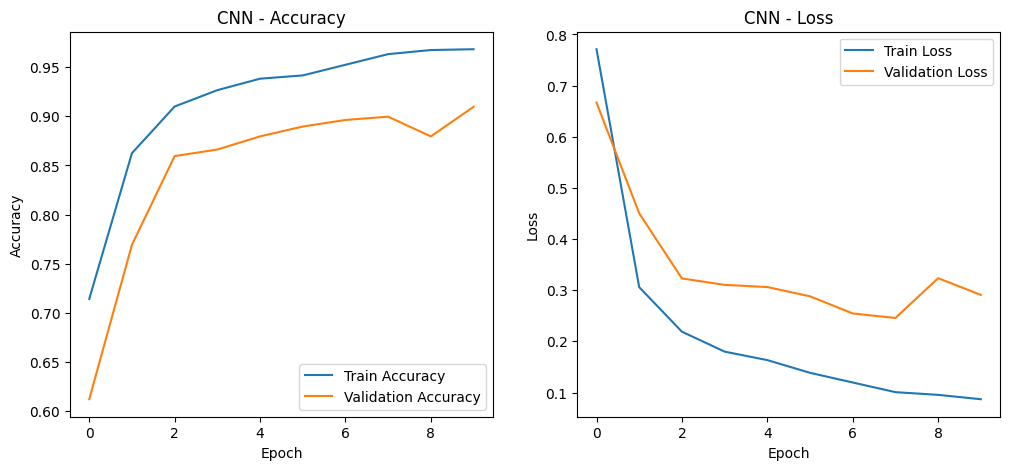



Grafik Arsitektur Transfer Learning


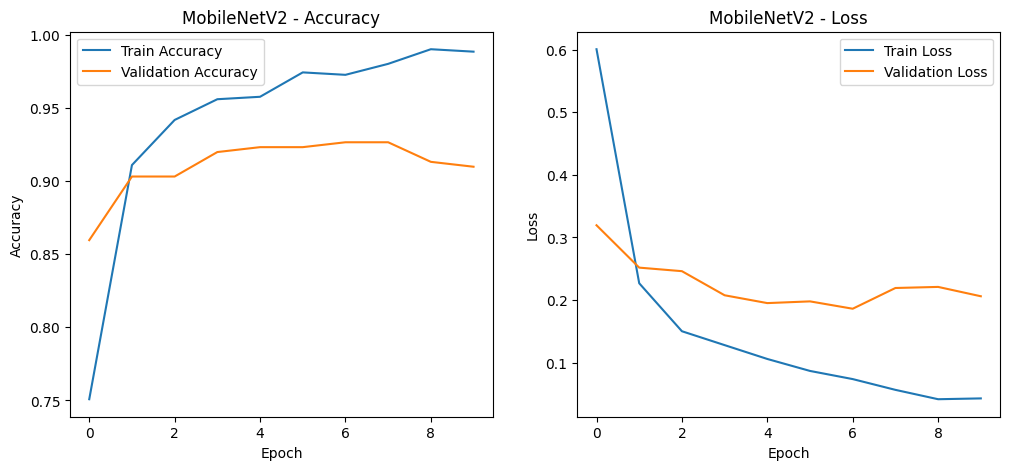

In [ ]:
print("Grafik Arsitektur CNN")

plt.figure(figsize=(12,5))

# Accuracy CNN
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss CNN
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

print('\n')
print("Grafik Arsitektur Transfer Learning")

plt.figure(figsize=(12,5))

# Accuracy MobileNetV2
plt.subplot(1,2,1)
plt.plot(history_transfer_learning.history['accuracy'], label='Train Accuracy')
plt.plot(history_transfer_learning.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss MobileNetV2
plt.subplot(1,2,2)
plt.plot(history_transfer_learning.history['loss'], label='Train Loss')
plt.plot(history_transfer_learning.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

**Tahap 3: Pemrosesan Teks & Klasifikasi Sentimen (RNN/LSTM)**

Ulasan pelanggan adalah data **sekuensial** — urutan kata membentuk makna. Contoh:
- *"Produk bagus, tidak mengecewakan"* → Positif
- *"Tidak bagus, mengecewakan"* → Negatif

Kata "tidak" sebelum "bagus" mengubah sentimen sepenuhnya. Metode ML konvensional seperti Naive Bayes atau Logistic Regression dengan **Bag of Words** tidak mampu menangkap konteks urutan ini.

**LSTM (Long Short-Term Memory)** adalah varian RNN yang secara eksplisit dirancang untuk mengingat dependensi jangka panjang dalam sekuens melalui mekanisme **gates**:
- **Forget Gate**: Memutuskan informasi lama apa yang dilupakan.
- **Input Gate**: Menentukan informasi baru apa yang disimpan.
- **Output Gate**: Mengontrol apa yang diteruskan ke state berikutnya.

### Tokenisasi
Mengubah kata menjadi angka (indeks integer) berdasarkan frekuensi kemunculan di corpus. Contoh:
`"produk bagus" → [142, 37]`

Parameter `num_words=5000` membatasi kosakata ke 5.000 kata paling sering — mengurangi dimensi embedding dan RAM yang diperlukan.

### Padding
LSTM membutuhkan input dengan panjang yang seragam. `pad_sequences(maxlen=50)` memotong ulasan yang terlalu panjang dan menambah angka 0 di awal untuk ulasan yang terlalu pendek.

In [ ]:
df_review = pd.read_csv('/content/reviews/tokopedia_product_reviews_2025.csv')

df_review = df_review[df_review['sentiment_label'] != 'neutral']

df_review = df_review.sample(n=10000, random_state=42)
df_review.head()

,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
53060,Sepatunya original bagus banget.pas d kaki aku...,2025-09-02,1657080195,PUMA Sepatu Lari Wanita Enzo 2 Metal Black-Gold,Olahraga,38,1299000,https://www.tokopedia.com/puma-official/puma-s...,100533810906,5,750,9110660,positive
4183,Enak bgt 🥺,2021-08-16,454053429,Roti Bunting Salju (minimal 9),Makanan & Minuman,lala vanila,18000,https://www.tokopedia.com/roti-eneng/roti-bunt...,2069370324,5,3000,8312452,positive
28048,GREAT🤩,2023-08-07,924420007,USAMS HEPA Filter For Vacuum Cleaner,Elektronik,Filter ZB108,49000,https://www.tokopedia.com/usamsidofficial/usam...,100266936467,5,250,9843521,positive
44016,diluar expektasi. aq pikir bakaln tipis2 gt ba...,2021-06-23,409090757,Dux Ducis Case Compatible for iPad Pro 12.9 20...,Handphone & Tablet,Hitam,249000,https://www.tokopedia.com/gojali/dux-ducis-cas...,1025553259,5,250,2298522,positive
51375,Kualitas bagus... Respon penjual super cepat,2023-08-11,926399223,2 Lembar Donic Formula Protector Foil Stiker P...,Olahraga,NaN,70000,https://www.tokopedia.com/astasport/donic-form...,1278300240,5,1000,2315766,positive


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

texts = df_review['review_text']
labels = df_review['sentiment_label']

le = LabelEncoder()
labels = le.fit_transform(labels)

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
padded = pad_sequences(sequences, maxlen=50)

X_train, X_val, y_train, y_val = train_test_split(
    padded, labels, test_size=0.2, random_state=42
)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weight:", class_weight_dict, "\n")

model_lstm = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=50),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

Label mapping: {'negative': np.int64(0), 'positive': np.int64(1)}
Class weight: {0: np.float64(40.816326530612244), 1: np.float64(0.5062009617818274)} 

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.8715 - loss: 0.7157 - val_accuracy: 0.7930 - val_loss: 0.3942
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.8605 - loss: 0.3019 - val_accuracy: 0.8385 - val_loss: 0.3185
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.9271 - loss: 0.1412 - val_accuracy: 0.9015 - val_loss: 0.2070
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.9655 - loss: 0.0900 - val_accuracy: 0.9560 - val_loss: 0.1038
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.9822 - loss: 0.0555 - val_accuracy: 0.9655 - val_loss: 0.1020
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.9783 - loss: 0.0561 - val_accuracy: 0.9675 - val_loss: 0.0937
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.987

Grafik Arsitektur Model LSTM


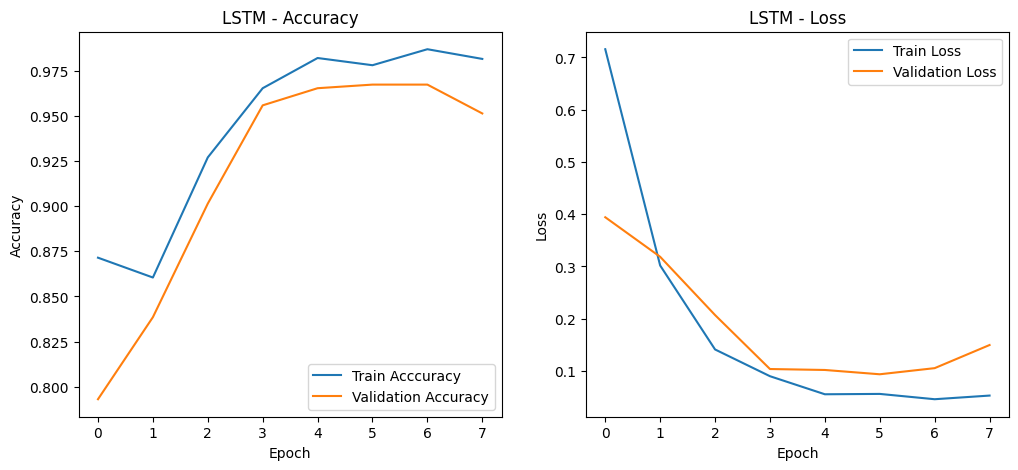


Evaluasi Akhir LSTM
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9675 - loss: 0.0937
Akurasi akhir: 0.9674999713897705


In [ ]:
print("Grafik Arsitektur Model LSTM")

plt.figure(figsize=(12,5))

# Accuracy CNN
plt.subplot(1,2,1)
plt.plot(history_lstm.history['accuracy'], label='Train Acccuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss LSTM
plt.subplot(1,2,2)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

print('\n'"Evaluasi Akhir LSTM")
loss, acc = model_lstm.evaluate(X_val, y_val)
print("Akurasi akhir:", acc)

**Tahap 4: Analisis Error & Keputusan Bisnis**


10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 785ms/step

Visualisasi Gambar Salah Prediksi


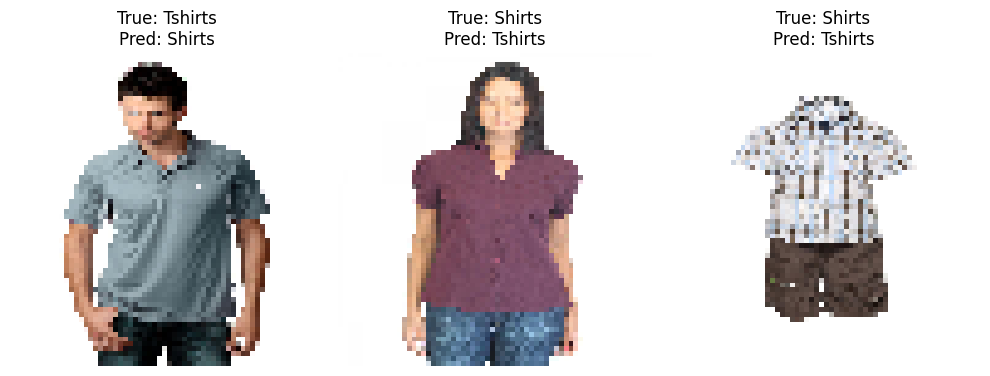

In [ ]:
val_data.reset()

images, true_labels = next(val_data)

y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)

true_classes = val_data.classes

wrong_idx = np.where(y_pred_classes != true_classes)[0]

class_names = list(val_data.class_indices.keys())

plt.figure(figsize=(10, 6))

for i, idx in enumerate(wrong_idx[:3]):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[idx])

    plt.title(
        f"True: {class_names[true_classes[idx]]}\n"
        f"Pred: {class_names[y_pred_classes[idx]]}"
    )
    plt.axis("off")

plt.tight_layout()
print("\n" "Visualisasi Gambar Salah Prediksi")
plt.show()

## Interpretasi Visualisasi Gambar yang Salah Diprediksi (Error Analysis CNN)

Memeriksa gambar yang salah diklasifikasikan adalah langkah krusial dalam pengembangan model produksi. Analisis ini membantu kita memahami:
- Apakah error bersifat sistematis (model selalu salah untuk tipe gambar tertentu)?
- Apakah resolusi rendah (64×64) adalah faktor utama kegagalan?
- Apakah ada overlap visual antar kategori yang membingungkan model?

### Hipotesis Kegagalan Model
Beberapa alasan potensial model CNN salah mengklasifikasikan:
1. **Resolusi rendah (64×64)**: Detail kritis seperti jahitan baju, logo jam, atau tekstur sepatu menjadi blur.
2. **Overlap visual**: Beberapa produk memiliki penampilan mirip lintas kategori (misal: sandal vs sepatu, jam tangan sport vs gelang).
3. **Latar belakang gambar**: Produk dengan background putih vs background model manusia memiliki distribusi piksel berbeda.
4. **Augmentasi terbatas**: Variasi sudut pengambilan foto yang tidak direpresentasikan dalam training.

## Kesimpulan Umum

Notebook ini telah membuktikan dua hal penting dalam konteks bisnis Fashion & Apparel di Tokopedia:

### Untuk Klasifikasi Gambar:
**Transfer Learning secara konsisten menghasilkan performa lebih baik** dibanding CNN yang dilatih dari nol, bahkan dengan dataset yang kecil dan resolusi gambar rendah. Ini menunjukkan kekuatan *inductive bias* dari model yang sudah melihat jutaan gambar.

### Untuk Analisis Sentimen:
**LSTM mampu menangkap nuansa bahasa** dalam ulasan pelanggan e-commerce Indonesia yang bersifat campuran dan informal — sesuatu yang tidak bisa dilakukan oleh metode statistik tradisional.

### Nilai Strategis:
Kedua model ini, jika diimplementasikan dalam sistem produksi, dapat **mengotomatisasi dua bottleneck operasional** utama: validasi konten upload seller dan monitoring kualitas ulasan — memungkinkan tim manusia untuk fokus pada keputusan yang membutuhkan judgment dan empati.
